### from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

In [73]:
import olefile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import os
%matplotlib inline

In [296]:
%load_ext autoreload
%autoreload 2

from vneo_method_parser import LCMethod
from lc_method_collection import LCMethodCollection
from ms_method_parser import MSMethod
from ms_method_collection import MSMethodCollection
from anndiannloader import DiannLoader as dl
from diann_collection import DiannCollection



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load LC Methods

#### LC Collection Object

In [3]:
lccollection = LCMethodCollection()

In [4]:
lccollection.add_methods_from_folder('/Users/eileen.wang/Desktop/diann/SampleData/methods/LC')

/Users/eileen.wang/Desktop/diann/code/vneo_method_parser.py:127: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/Users/eileen.wang/Desktop/diann/code/vneo_method_parser.py:130: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


In [5]:
# lc_methods = '\n'.join(lccollection.methods.keys())
# print(f'Methods loaded: {len(lccollection.methods.keys())}\n{lc_methods}')

<Axes: title={'center': 'Gradient Comparison: 20m150nlv15, 23p75m150nlv16, 17p5m150nlv13, 36m150nlLong40, 25m150nlv5, 17p7m150nlv11, 25m200nlv5, 10m150nlRainmanA15-75, 20m150nlML23p5mA15v1, 25m150nlv4, 16m150nlv8, 23p75mHighACNWash150nlv17, 20p5m150nlv7, 20p5m150nlv6, 20m150nlML30mA15phospho4, 17p5m150nlv10, 20p5m150nlv14, 23p65m150nlv18Zebra, 11p5m150nlv9, 24m150nlThermo, 36m150nlSlow40, 27m150nlv3, 17p75m150nlv12, 20m150nlML30mA15v2'}, xlabel='time [min]', ylabel='Value [%]'>

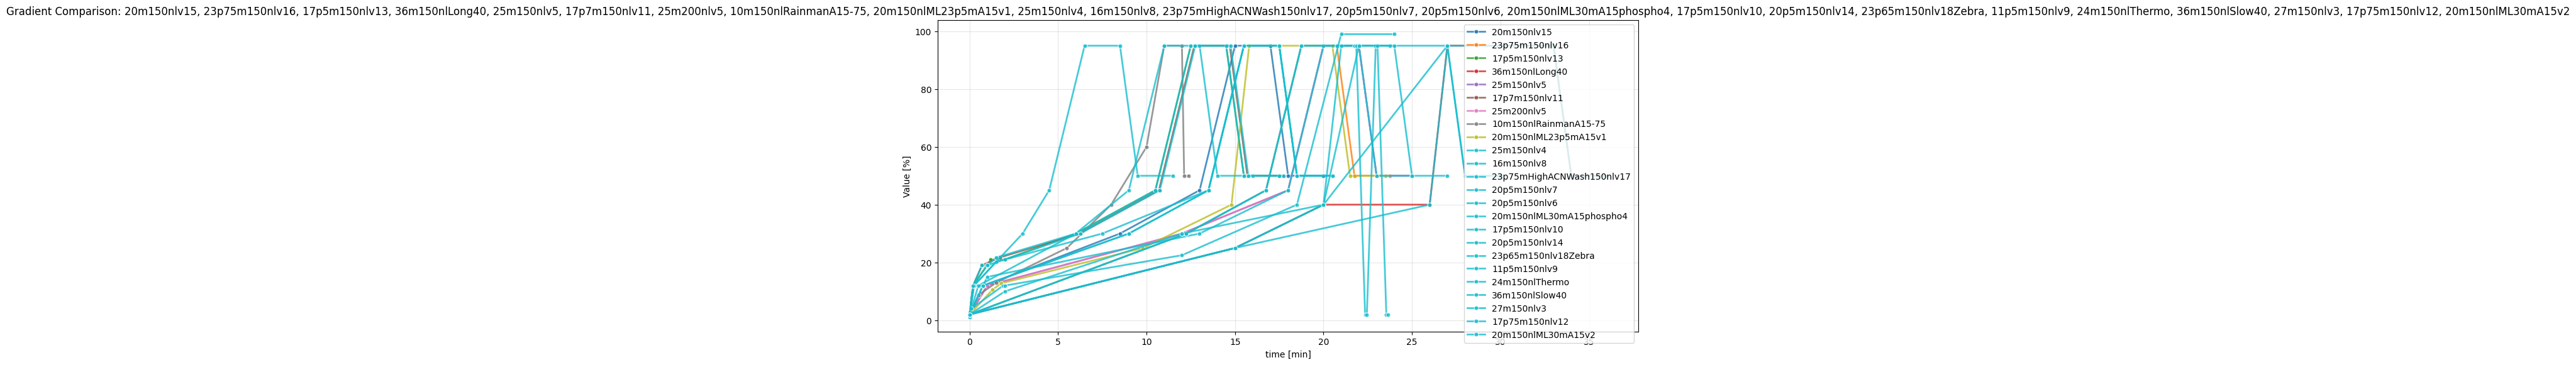

In [612]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.%B.Value [%]'], 
                        twin_axes=True , 
                        markers=True
)

''

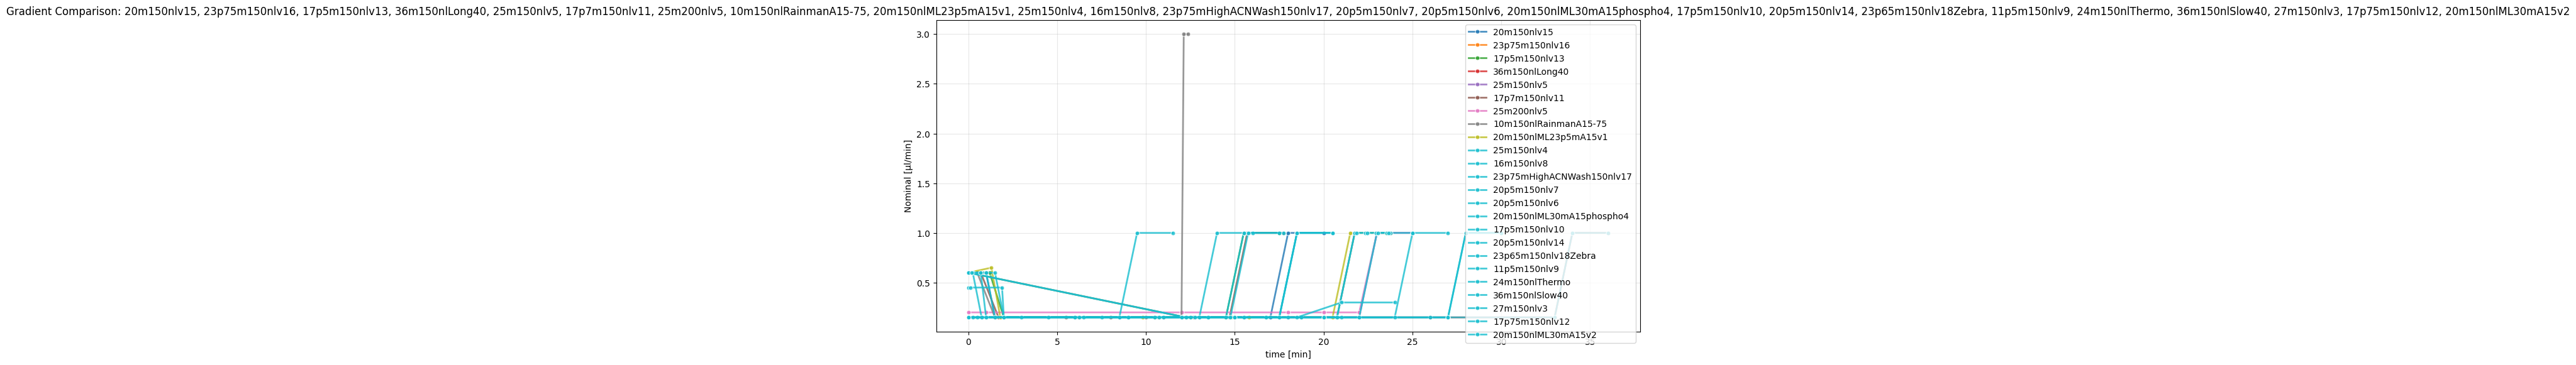

In [611]:
lccollection.plot_gradients(
                        x_col = 'time [min]',
                        y_cols = ['Neo.PumpModule.Pump.Flow.Nominal [µl/min]'], 
                        twin_axes=True , 
                        markers=True
)
, 

## MS Methods

## Load MS Methods

In [6]:
# Intialize MS method collector object
mscollection = MSMethodCollection()


In [7]:
# # Method 1: Add single method with explicit name
# collection.add_method("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m")

# Method 2: Add from zip file (extracts and adds all methods inside)
mscollection.add_methods_from_folder("/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/260130_11AM.zip")
# collection.add_methods_from_paths(["/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m"], overwrite = 'ignore')
msmethod_names = '\n'.join(mscollection.methods.keys())
# print(f"Loaded {len(mscollection)} methods: {msmethod_names}")


### MS Meth Summary

In [849]:
# mscollection.summary_df()

### Find Differences between methods

In [954]:
method = mscollection['DIA011RT70expandedrange.proteoscape']
value = method['Collision_GasSupply_Set']  # Direct access!
# cap_voltage = method['default_Source_CapillarySetValue']  # Positive only
windows = method['dia_windows']  # Direct access!


In [955]:
mscollection

MSMethodCollection(n_methods=46)

In [964]:
df = mscollection.to_dataframe(
    method_names=['DIA007.proteoscape', 'DIA016.proteoscape'],  # Optional: subset methods
    # param_names=['Collision_GasSupply_Set', 'dia_window_count'],  # Optional: subset params
    exclude_dia_windows=True  # Exclude DataFrame objects by default
)

In [31]:
df = mscollection.to_dataframe()

In [49]:
## MS mass start/end
# df[['Mode_ScanBegin', 'Mode_ScanEnd']]

In [966]:
# finding differences between 2+ methods
diff = mscollection.find_differences(['DIA011RT60.proteoscape','DIA018.proteoscape'])
diff

,Parameter,Type,Description,DIA011RT60.proteoscape,DIA018.proteoscape
0,Vacuum_LastCapillaryCleaningDate,instrument_param,,2025-11-24T12:05:17-08:00,2025-08-18T09:57:05-07:00
1,TOF_DetectorTofSetValue,instrument_param,,2265.0,2252.0
2,default_IMS_Calibration_RampVelocity_Save,polarity_param,positive polarity,0.205078,0.427318
3,default_IMS_Calibration_LastCalibrationDate,polarity_param,positive polarity,2025-09-10T17:35:19-07:00,2025-09-11T11:46:42-07:00
4,default_IMS_CalibrationRampEnd,polarity_param,positive polarity,139.972162,140.502687
5,default_IMS_Calibration_LastCalibrationMassInt...,polarity_param,positive polarity,"[1445930.0230822468, 1471710.2676116882, 75735...","[787028.996186168, 1230470.924191452, 177976.4..."
6,default_IMS_Calibration_Funnel1In_Pressure,polarity_param,positive polarity,2.387,2.403
7,default_IMS_CalibrationCoefficients,polarity_param,positive polarity,"[0.03084927968991898, 160.35509090775577, 15.9...","[0.001523152265349233, 165.08327143248422, 16...."
8,default_IMS_CalibrationRampStart,polarity_param,positive polarity,243.402636,239.900581
9,default_IMS_Calibration_StdDev,polarity_param,positive polarity,0.000138,0.000599


#### Plotting differences

No numeric parameters found to plot


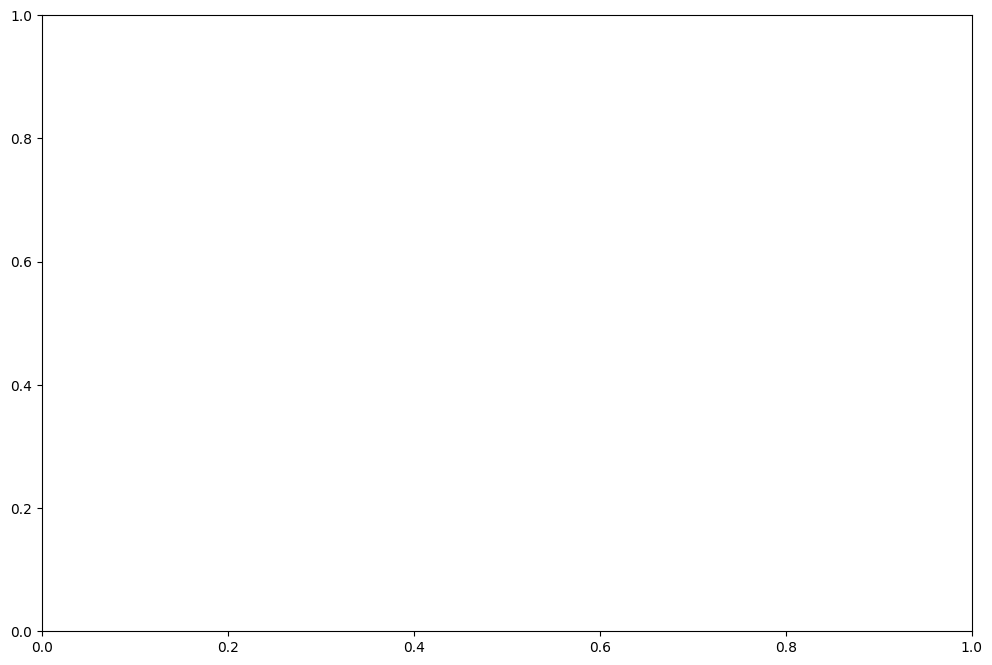

In [971]:
mscollection.plot_differences(method_names = ['DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011RT60.proteoscape',
'DIA018.proteoscape',
'DIA011QC2v1600.proteoscape'],
)

### Plot DIA Windows

<Axes: title={'center': 'DIA Windows Overlay: DIA011RT60.proteoscape, DIA018.proteoscape'}, xlabel='m/z', ylabel='1/K0 (Ion Mobility)'>

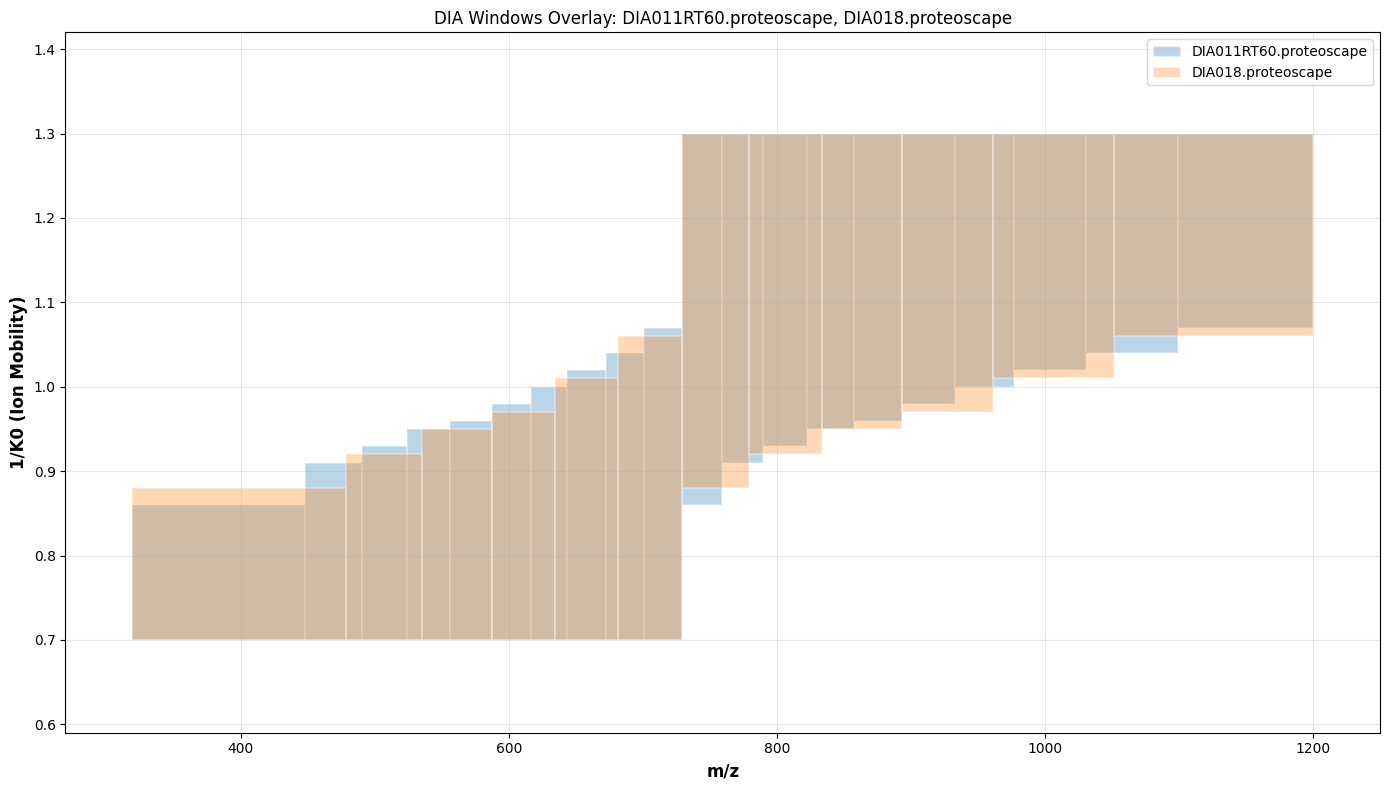

In [902]:
mscollection.plot_windows(['DIA011RT60.proteoscape', 'DIA018.proteoscape'], color_by_method=True,
                    alpha=0.3,
                    # edge_color='white',
                    # figsize=(14, 8),
                    show_labels=False)

## Loading Searches

In [149]:
samplecollection = DiannCollection(log_file = '/Users/eileen.wang/Desktop/diann/log/sample_collection_log.txt')

for i in ['5bb65d07aa6a2f77f81b5e08ab034d2b', 
          '91e1fd4b7eb0d9bcc1efe2d697ec6237',
          '4032c8c9eb896d865ede0acf6854adbd',
          'e086878c8a63cdb635efbfdfc701b60b'
         ]:

    samplecollection.add_from_folder(f"/Users/eileen.wang/Desktop/diann/SampleData/BPS/{i}.zip", levels=["precursor", "protein"])
                                 
    
    # Access data
    # adata = collection['sample1', 'precursor']
    # print(f"Shape: {adata.shape}")
    
    # Summary
    # summary = collection.summary_df()
    # print(summary)
    
#     # Save
#     collection.save("my_collection.pkl")

# # Load later
# collection = DiannCollection.from_file("my_collection.pkl")


/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'precursor': {'Averagine', 'Translated.Quality', 'Global.Q.Value', 'Mass.Evidence', 'Lib.Index', 'Precursor.Mz', 'Ms1.Translated', 'Precursor.Translated', 'Predicted.IM', 'Predicted.iIM', 'PEP', 'IM', 'Spectrum.Similarity', 'Translated.Q.Value', 'All Mapped Genes', 'All Mapped Proteins', 'iIM'}
  warnings.warn(msg)


Loaded 79257 rows with 44/61 columns for level 'precursor'
Missing columns: {'Averagine', 'Translated.Quality', 'Global.Q.Value', 'Mass.Evidence', 'Lib.Index', 'Precursor.Mz', 'Ms1.Translated', 'Precursor.Translated', 'Predicted.IM', 'Predicted.iIM', 'PEP', 'IM', 'Spectrum.Similarity', 'Translated.Q.Value', 'All Mapped Genes', 'All Mapped Proteins', 'iIM'}
Using 'Precursor.Id' as obs_name (unique values)
Using 'File.Name' as var_name
Using 'Precursor.Quantity' as x (quantification column)


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'protein': {'Global.PG.Q.Value', 'Lib.PG.Q.Value'}
  warnings.warn(msg)


Loaded 79257 rows with 14/16 columns for level 'protein'
Missing columns: {'Global.PG.Q.Value', 'Lib.PG.Q.Value'}
Using 'Protein.Ids' as obs_name (unique values)
Using 'File.Name' as var_name
Using 'PG.MaxLFQ' as x (quantification column)


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'precursor': {'Averagine', 'Translated.Quality', 'Global.Q.Value', 'Mass.Evidence', 'Lib.Index', 'Precursor.Mz', 'Ms1.Translated', 'Precursor.Translated', 'Predicted.IM', 'Predicted.iIM', 'PEP', 'IM', 'Spectrum.Similarity', 'Translated.Q.Value', 'All Mapped Genes', 'All Mapped Proteins', 'iIM'}
  warnings.warn(msg)


...

/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'precursor': {'Averagine', 'Translated.Quality', 'Global.Q.Value', 'Mass.Evidence', 'Lib.Index', 'Precursor.Mz', 'Ms1.Translated', 'Precursor.Translated', 'Predicted.IM', 'Predicted.iIM', 'PEP', 'IM', 'Spectrum.Similarity', 'Translated.Q.Value', 'All Mapped Genes', 'All Mapped Proteins', 'iIM'}
  warnings.warn(msg)


Loaded 94143 rows with 44/61 columns for level 'precursor'
Missing columns: {'Averagine', 'Translated.Quality', 'Global.Q.Value', 'Mass.Evidence', 'Lib.Index', 'Precursor.Mz', 'Ms1.Translated', 'Precursor.Translated', 'Predicted.IM', 'Predicted.iIM', 'PEP', 'IM', 'Spectrum.Similarity', 'Translated.Q.Value', 'All Mapped Genes', 'All Mapped Proteins', 'iIM'}
Using 'Precursor.Id' as obs_name (unique values)
Using 'File.Name' as var_name
Using 'Precursor.Quantity' as x (quantification column)


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'protein': {'Global.PG.Q.Value', 'Lib.PG.Q.Value'}
  warnings.warn(msg)


Loaded 94143 rows with 14/16 columns for level 'protein'
Missing columns: {'Global.PG.Q.Value', 'Lib.PG.Q.Value'}
Using 'Protein.Ids' as obs_name (unique values)
Using 'File.Name' as var_name
Using 'PG.MaxLFQ' as x (quantification column)


/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Combine Sample and Method

In [ ]:
from filter_utils import filter_collection

# Default quality filtering
filtered = filter_collection(collection, 'precursor')

# Custom thresholds
filtered = filter_collection(
    collection,
    'precursor',
    layer_thresholds={
        'Q.Value': (0.01, 'max'),      # Keep Q-value <= 0.01
        'RT': (10.0, 'min'),           # Keep RT >= 10 minutes
        'RT.Stop': (50.0, 'max')       # Keep RT <= 50 minutes
    }
)

In [1060]:
def filter(ad, filter_name = 'mask', strict=False, layer_threshold={'Q.Value': (0.01, 'max'),'PG.Q.Value': (0.05, 'max'), 'Lib.Q.Value': (0.01, 'max'), 'Lib.PG.Q.Value': (0.05, 'max')}):
    ad = ad.copy()
    ad.layers[filter_name] = np.ones((ad.n_obs, ad.n_vars), dtype=bool)

    for layer, threshold in layer_threshold.items():
        layer_exists = layer in ad.layers
        if not layer_exists:
            if strict:
                raise ValueError(f"Layer '{layer}' not found in AnnData layers.")
            else:
                print(f"Warning: Layer '{layer}' not found in AnnData layers. Skipping this threshold.")
                continue
        
        #TODO: print number of filterd values. make sure to distinguish between not idnetiifed in the first place vs filterd out
        if threshold[1] == 'max':
            mask = ad.layers[layer] <= threshold[0]
            ad.layers[filter_name] = ad.layers[filter_name] & mask
        elif threshold[1] == 'min':
            mask = ad.layers[layer] >= threshold[0]
            ad.layers[filter_name] = ad.layers[filter_name] & mask
        elif threshold[1] == 'equal':
            mask = ad.layers[layer] == threshold[0]
            ad.layers[filter_name] = ad.layers[filter_name] & mask
            
    return ad

In [1039]:
def precursor_hist(ad, samples, x='RT', mask=['Precursor.Quantity', 'mask'], ax=None, alpha=0.5):
    for s in samples:
        temp = ad[:, s]
        if ax:
            sns.histplot(temp.layers[x], ax=ax, alpha=0.5)
        else:
            sns.histplot(temp.layers[x], alpha=alpha)

def precursor_scatter(ad, samples, x='RT', y='Intensity', mask=['Precursor.Quantity', 'mask'], ax=None, alpha=0.5):
    for s in samples:
        temp = ad[:, s]
        if ax:
            sns.scatterplot(x = temp.layers[x], y = temp.layers[y], ax=ax, alpha=0.5)
        else:
            sns.scatterplot(x = temp.layers[x], y = temp.layers[y], alpha=alpha)

def precursor_hist(collection, level, samples, x='RT', ax=None, alpha=0.5):
    ad = collection.data[level]
    for s in samples:
        temp = ad[:, s]
        if ax:
            sns.histplot(temp.layers[x], ax=ax, alpha=0.5)
        else:
            sns.histplot(temp.layers[x], alpha=alpha)

In [1059]:
filtered_precursor = filter(samplecollection['precursor'])
filtered_samples = filtered_precursor[:, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620']

[ 1  2  1 ...  1 10  4]
[ 1  2  1 ...  1 10  4]


In [ ]:
# mask = filtered_samples.layers['mask'] & (filtered_samples.layers['Precursor.Quantity'] > 0)

In [12]:
# sns.violinplot(filtered_samples.layers['Precursor.FWHM'][filtered_samples.layers['mask']])
# sns.violinplot(sample.layers['Precursor.FWHM'])

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


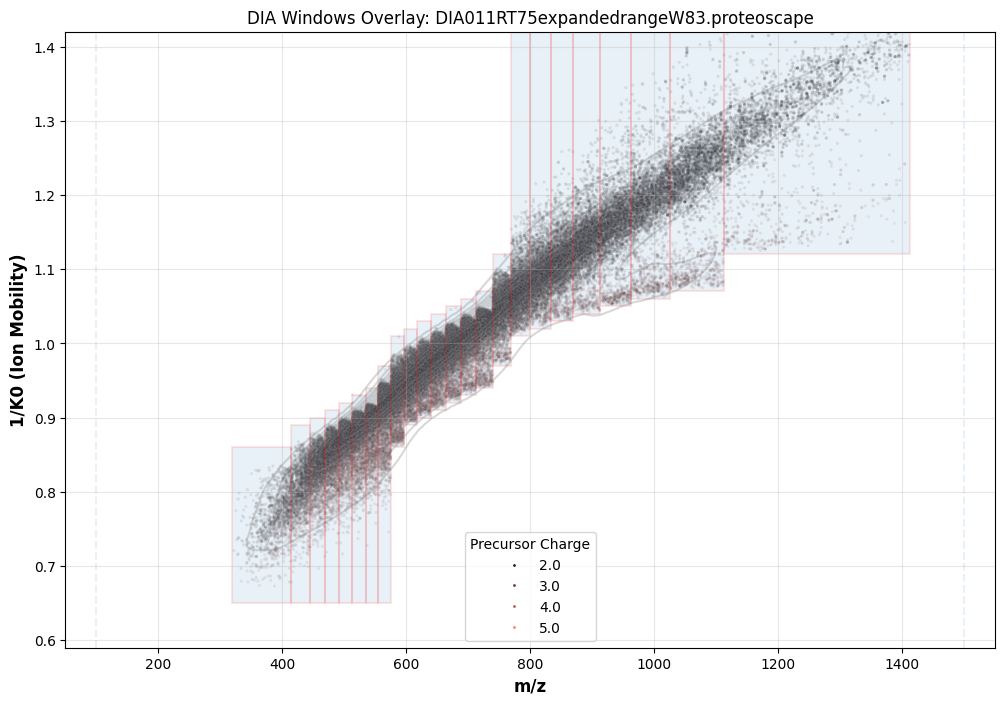

In [77]:
fig, ax = plt.subplots(figsize=(12, 8))
adata = samplecollection.data['precursor']
sample = adata[:, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620']

# 1. Plot DIA windows first (m/z × IM space)


# Scatter plot of precursors
sns.scatterplot(
    x = sample.layers['Precursor.Calibrated.Mz'][:, 0], 
    y = sample.layers['Exp.1/K0'][:, 0],
    hue = sample.obs['Precursor.Charge'].values,
    palette=sns.color_palette("dark:salmon", as_cmap=True),
    s=5, 
    alpha=0.1,
    ax=ax)



mscollection.plot_windows(['DIA011RT75expandedrangeW83.proteoscape'], 
                          color_by_method=True,
                          alpha=0.1,
                          show_labels=False,
                          edge_color ='red',
                          ax=ax)

sns.kdeplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), 
           y = sample.layers['Exp.1/K0'].flatten(),
           s=1, 
           alpha=0.3, 
           color='grey',
           ax=ax)

ax.legend(title='Precursor Charge')

legend = ax.legend_
for lh in legend.legend_handles:
    lh.set_alpha(1) # Set alpha to 1 (fully opaque)
    lh._sizes = [250]

# plt.tight_layout()


#### Ion Mobility Errir

(-0.2, 0.2)

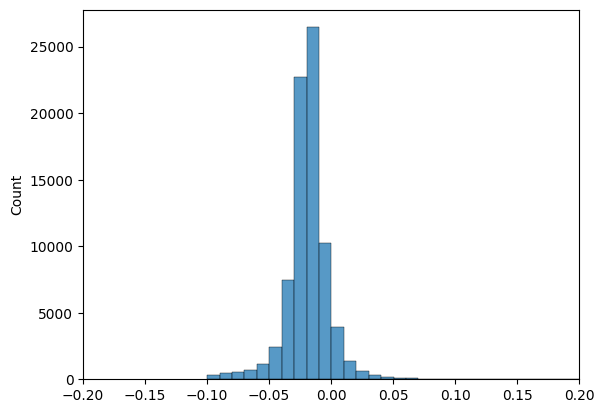

In [66]:
sns.histplot((sample.layers['Lib.1/K0'] - sample.layers['Exp.1/K0']).flatten(), binwidth =0.01)
plt.xlim(-0.2, 0.2)

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


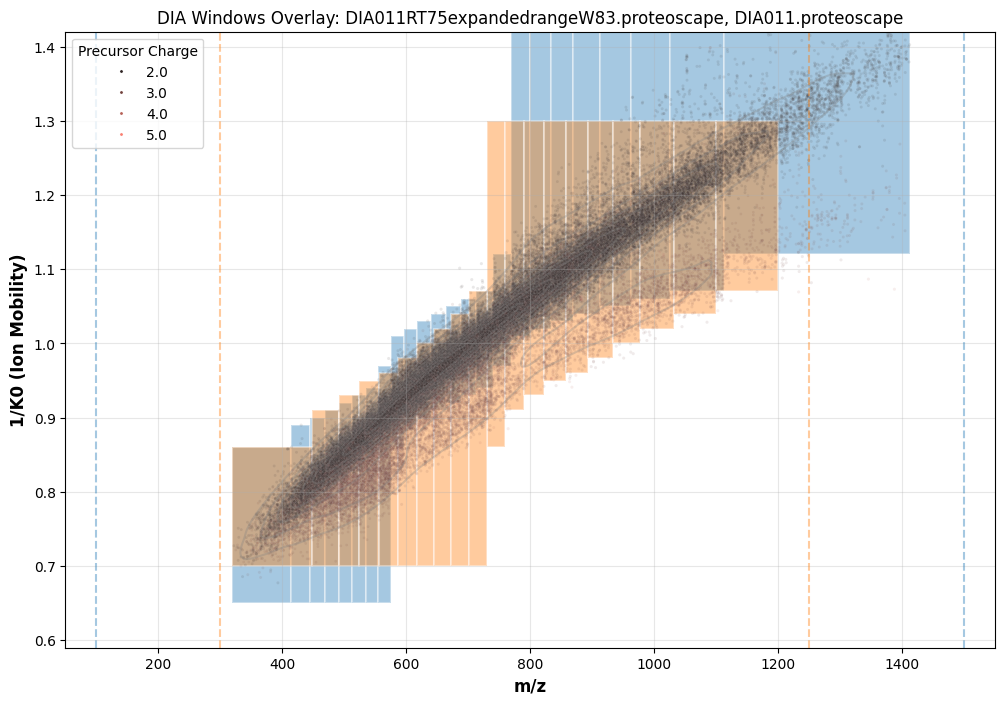

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
adata = samplecollection.data['precursor']
sample = adata[:, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_17p75m150nlv12_DIA75msW83_TT0000219_B-B1_1_14620']

# 1. Plot DIA windows first (m/z × IM space)
sns.kdeplot(x = sample.layers['Precursor.Calibrated.Mz'].flatten(), 
           y = sample.layers['Lib.1/K0'].flatten(),
           s=1, 
           alpha=0.3, 
           color='grey',
           ax=ax)

mscollection.plot_windows(['DIA011RT75expandedrangeW83.proteoscape', 'DIA011.proteoscape'], 
                          color_by_method=True,
                          alpha=0.4,
                          show_labels=False, 
                          ax=ax)

# Scatter plot of precursors
sns.scatterplot(
    x = sample.layers['Precursor.Calibrated.Mz'][:, 0], 
    y = sample.layers['Lib.1/K0'][:, 0],
    hue = sample.obs['Precursor.Charge'].values,
    palette=sns.color_palette("dark:salmon", as_cmap=True),
    s=5, 
    alpha=0.1,
    ax=ax)

ax.legend(title='Precursor Charge')

legend = ax.legend_
for lh in legend.legend_handles:
    lh.set_alpha(1) # Set alpha to 1 (fully opaque)
    lh._sizes = [250

# plt.tight_layout()


## Matching Methods to Samples

In [70]:
df = pd.read_csv('/Users/eileen.wang/Desktop/diann/SampleData/Sequences/2026_01_lcmsmethodmapping.csv')

In [222]:
test = samplecollection['precursor'].copy()

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [233]:
# for level in samplecollection.data.keys():
#     adata = samplecollection[level]
test.var = test.var.join(df[['LCmeth', 'MSmeth', 'sample']].set_index('sample'), how='left')

In [223]:
duplicates = test.var.duplicated(keep='first')

test = test[:, ~duplicates]

In [204]:
def plot_precursor_mz_im(adata, s, mscollection, ms_method='sample', mz ='Precursor.Calibrated.Mz', im='Exp.1/K0'):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sample = adata[:, s]

    # 1. Plot DIA windows first (m/z × IM space)
    sns.kdeplot(x = sample.layers[mz].flatten(), 
            y = sample.layers[im].flatten(),
            s=1, 
            alpha=0.3, 
            color='grey',
            ax=ax)

    if ms_method == 'sample':
        meth = adata.var.loc[s, 'MSmeth']
        mscollection.plot_windows([meth], 
                                color_by_method=True,
                                alpha=0.4,
                                show_labels=False, 
                                ax=ax)

    # Scatter plot of precursors
    sns.scatterplot(
        x = sample.layers[mz][:, 0], 
        y = sample.layers[im][:, 0],
        hue = sample.obs['Precursor.Charge'].values,
        palette=sns.color_palette("dark:salmon", as_cmap=True),
        s=5, 
        alpha=0.1,
        ax=ax)

    ax.legend(title='Precursor Charge')

    legend = ax.legend_
    for lh in legend.legend_handles:
        lh.set_alpha(1) # Set alpha to 1 (fully opaque)
        lh._sizes = [250]

    # plt.tight_layout()


In [224]:
test.var['hystar_idx'] = test.var['File.Name'].str.extract('.+_(\d+)$')

/var/folders/fw/_hz2f4mj6pdc3ffplz4b82lc0000gq/T/ipykernel_22839/853797646.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  test.var['hystar_idx'] = test.var['File.Name'].str.extract('.+_(\d+)$')


In [235]:
test.var.sort_values('hystar_idx')

,File.Name,UUID,search_type,hystar_idx,LCmeth,MSmeth
File.Name,,,,,,
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000182_B-B11_1_14584,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,315edb4e-dcc0-4a4c-8b11-450c747036b6,bps,14584,20m150nlML30mA15phospho4,DIA003.proteoscape
Blank_01FA_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000183_B-A1_1_14585,Blank_01FA_2uL_VNeo_Aurora15_16_20min_DIA003_T...,fa573e5b-66ac-40f4-859a-d1051d7d92d2,bps,14585,20m150nlML30mA15phospho4,DIA003.proteoscape
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20minv2_DIA003_TT0000185_B-B11_1_14586,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,e7a30a9d-5205-4884-aa6e-8eab8474aec6,bps,14586,20m150nlML30mA15phospho4,DIA003.proteoscape
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000187_B-B11_1_14588,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,42481e6a-125e-4313-9ab8-5c4b1471fd09,bps,14588,20m150nlML30mA15phospho4,DIA003.proteoscape
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_36m150nlLong40_DIA003_TT0000188_B-B11_1_14589,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,9f31759b-3a6e-4eb6-aaf3-1d5c708e5758,bps,14589,36m150nlLong40,DIA003.proteoscape
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_36m150nlSlow40_DIA003_TT0000189_B-B11_1_14590,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,0ea3c410-09ea-4b20-b8df-65b95fbddf53,bps,14590,36m150nlSlow40,DIA003.proteoscape
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_27m150nlv3_DIA003_TT0000190_B-B11_1_14591,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,36f264a4-ec30-494d-ad90-7145ebafc88e,bps,14591,27m150nlv3,DIA003.proteoscape
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_25m150nlv4_DIA003_TT0000191_B-B11_1_14592,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,b7250074-0f44-42b9-8ee1-d562fae77a8c,bps,14592,25m150nlv4,DIA003.proteoscape
HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_24m150nlThermo_DIA003_TT0000192_B-B11_1_14593,HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_...,43f0743c-9cef-4b9b-9d4a-bf8c4240f358,bps,14593,24m150nlThermo,DIA003.proteoscape


In [240]:
test.var_names[test.var['hystar_idx']=='14584']

Index(['HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000182_B-B11_1_14584'], dtype='object', name='File.Name')

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


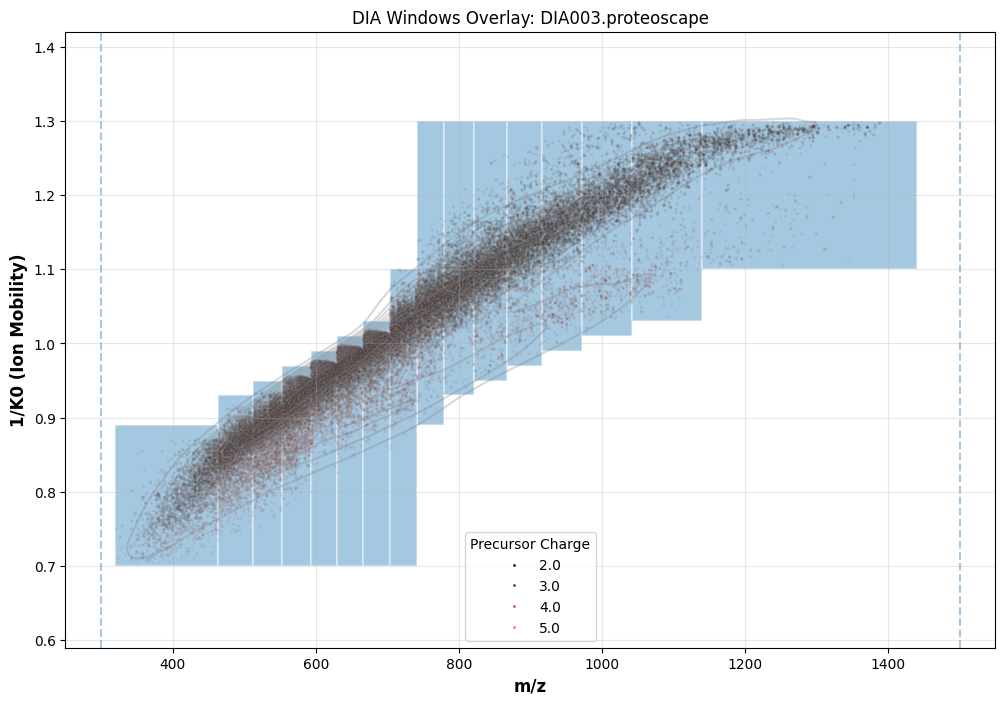

In [241]:
plot_precursor_mz_im(test, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20min_DIA003_TT0000182_B-B11_1_14584', mscollection)

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


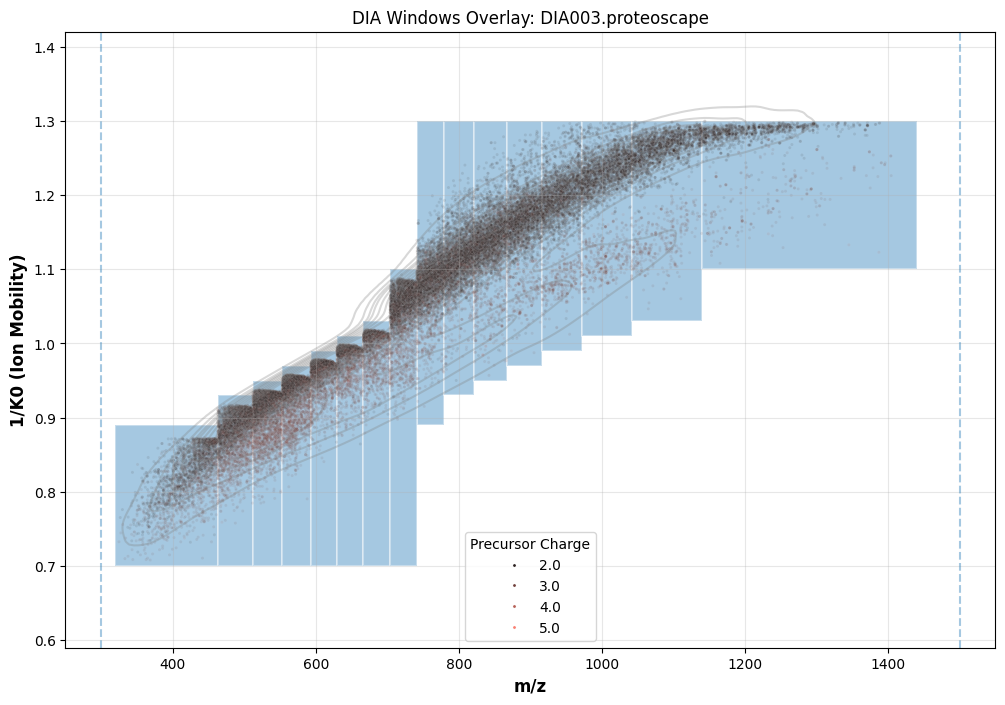

In [237]:
plot_precursor_mz_im(test, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_27m150nlv3_DIA003_TT0000190_B-B11_1_14591', mscollection)

/opt/anaconda3/envs/diann_report_venv/lib/python3.9/site-packages/seaborn/distributions.py:1176: UserWarning: The following kwargs were not used by contour: 's'
  cset = contour_func(


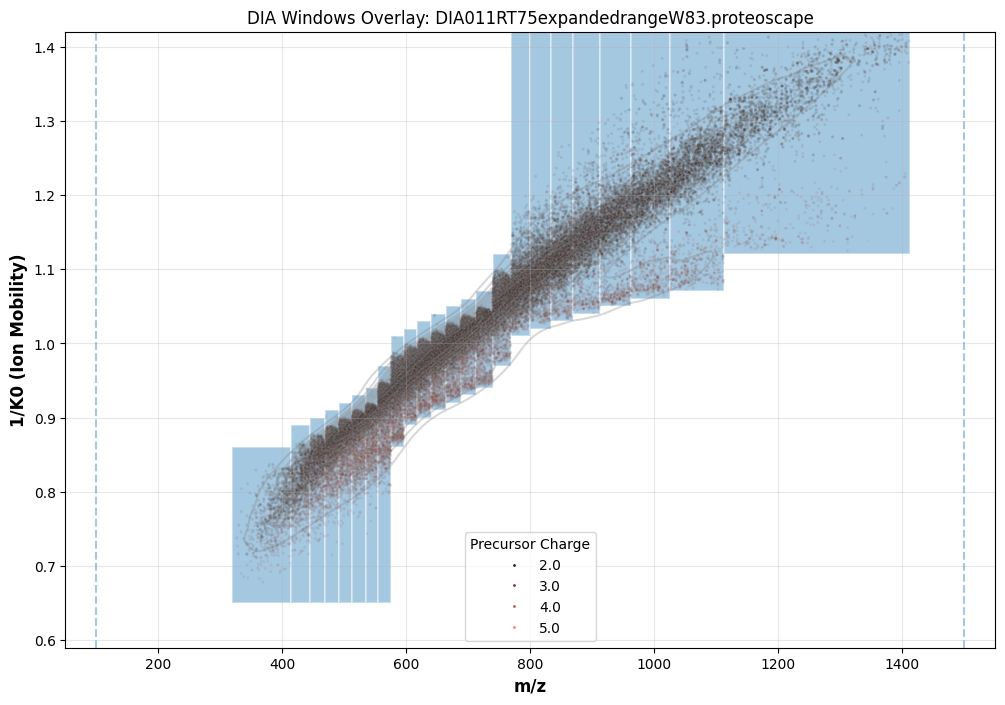

In [234]:
plot_precursor_mz_im(test, 'HeLa_20ng_2ACN01TFA_0015DDM_2uL_VNeo_Aurora15_16_20p5m150nlv5_DIA75msW83_TT0000215_B-B1_1_14616', mscollection)

## FP Reading in

In [297]:
fpcollection = DiannCollection(log_file = '/Users/eileen.wang/Desktop/diann/log/fp_sample_collection_log.txt')

In [298]:
fpcollection.add_single_search("/Users/eileen.wang/Desktop/diann/SampleData/FP/FP_100pg20ng_25m/report.tsv", search_type='fragpipe')

/Users/eileen.wang/Desktop/diann/code/anndiannloader.py:202: UserWarning: Missing columns for level 'precursor': {'Fragment.Calibrated.Mz', 'Lib.1/K0', 'Ms1.Iso.Corr.Sum', 'Precursor.Calibrated.Mz', 'Library.Precursor.Mz', 'Corrected.Precursor.Mz', 'Corr.Precursor.Error.Ppm', 'Precursor.FWHM', 'Precursor.Error.Ppm', 'Data.Points', 'Exp.1/K0'}
  warnings.warn(msg)


Loaded 422497 rows with 50/61 columns for level 'precursor'
Missing columns: {'Fragment.Calibrated.Mz', 'Lib.1/K0', 'Ms1.Iso.Corr.Sum', 'Precursor.Calibrated.Mz', 'Library.Precursor.Mz', 'Corrected.Precursor.Mz', 'Corr.Precursor.Error.Ppm', 'Precursor.FWHM', 'Precursor.Error.Ppm', 'Data.Points', 'Exp.1/K0'}
Using 'Precursor.Id' as obs_name
Using 'File.Name' as var_name
Using 'Precursor.Quantity' as x (quantification column)
Loaded 422497 rows with 16/16 columns for level 'protein'
Using 'Protein.Ids' as obs_name
Using 'File.Name' as var_name
Using 'PG.MaxLFQ' as x (quantification column)
Loaded 422497 rows with 8/8 columns for level 'gene'
Using 'Genes' as obs_name
Using 'File.Name' as var_name
Using 'Genes.MaxLFQ' as x (quantification column)


In [299]:
fpcollection.data

{}

# Analyzing Methods

1. How many precursors are being collected/detected per cycle?
2. How many precusors are being collected per unit time?
3. What percentage of precursors do our DIA windows collect?
   * Which precursors does it leave out?
   * Evaluating window size vs precursors actually in a window per unit time? 
4. What is the difference in number of precursors detected per sample/run?
   * How do they plot in terms of RT, IM, MZ, etc
5. Carryover?
   * % of total intensity 
   * % vs intensity in previous sample
   * properties of carrover/distribution vs RT

In [ ]:
adata.raw = adata.copy()
